In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn import model_selection
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    precision_recall_fscore_support, ConfusionMatrixDisplay, roc_auc_score
)
from imblearn.under_sampling import NearMiss
from xgboost import XGBClassifier

### Dataset Description
<li>Jm1 is a dataset created by NASA to predict software defects</li>
<li>Dataset consists of 22 attributes and 10885 instances</li>
<li>First 21 attributes represent features of the code; last attribute is a boolean indicating whether the software contains defects</li>
<li>21 attributes: 5 code measures, 3 McCabe metrics, 4 base Halstead measures, 8 derived Halstead measures, and branch-count</li>

## Step 1 — Load & Basic Cleaning

In [29]:
Dataset = pd.read_csv('jm1_csv.csv')
print("Shape:", Dataset.shape)
Dataset.head()

Shape: (10885, 22)


,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,2,2,2,2,1.2,1.2,1.2,1.2,1.4,False
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1,1,1,1,1.0,1.0,1.0,1.0,1.0,True
2,72.0,7.0,1.0,6.0,198.0,1134.13,0.05,20.31,55.85,23029.10,...,51,10,8,1,17.0,36.0,112.0,86.0,13.0,True
3,190.0,3.0,1.0,3.0,600.0,4348.76,0.06,17.06,254.87,74202.67,...,129,29,28,2,17.0,135.0,329.0,271.0,5.0,True
4,37.0,4.0,1.0,4.0,126.0,599.12,0.06,17.19,34.86,10297.30,...,28,1,6,0,11.0,16.0,76.0,50.0,7.0,True


In [30]:
Dataset.isnull().sum()

loc                  0
v(g)                 0
ev(g)                0
iv(g)                0
n                    0
v                    0
l                    0
d                    0
i                    0
e                    0
b                    0
t                    0
lOCode               0
lOComment            0
lOBlank              0
locCodeAndComment    0
uniq_Op              5
uniq_Opnd            5
total_Op             5
total_Opnd           5
branchCount          5
defects              0
dtype: int64

In [31]:
Dataset.dtypes

loc                  float64
v(g)                 float64
ev(g)                float64
iv(g)                float64
n                    float64
v                    float64
l                    float64
d                    float64
i                    float64
e                    float64
b                    float64
t                    float64
lOCode                 int64
lOComment              int64
lOBlank                int64
locCodeAndComment      int64
uniq_Op              float64
uniq_Opnd            float64
total_Op             float64
total_Opnd           float64
branchCount          float64
defects                 bool
dtype: object

In [32]:
# Convert defects to float and drop rows with missing values
Dataset['defects'] = Dataset['defects'].astype('float')
Dataset.dropna(axis=0, inplace=True)
print("Shape after cleaning:", Dataset.shape)
Dataset.head()

Shape after cleaning: (10880, 22)


,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,2,2,2,2,1.2,1.2,1.2,1.2,1.4,0.0
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1,1,1,1,1.0,1.0,1.0,1.0,1.0,1.0
2,72.0,7.0,1.0,6.0,198.0,1134.13,0.05,20.31,55.85,23029.10,...,51,10,8,1,17.0,36.0,112.0,86.0,13.0,1.0
3,190.0,3.0,1.0,3.0,600.0,4348.76,0.06,17.06,254.87,74202.67,...,129,29,28,2,17.0,135.0,329.0,271.0,5.0,1.0
4,37.0,4.0,1.0,4.0,126.0,599.12,0.06,17.19,34.86,10297.30,...,28,1,6,0,11.0,16.0,76.0,50.0,7.0,1.0


## Step 2 — Exploratory Data Analysis

In [6]:
from IPython.core.display import HTML
HTML("""<style>.output_png { display: table-cell; text-align: center; }</style>""")

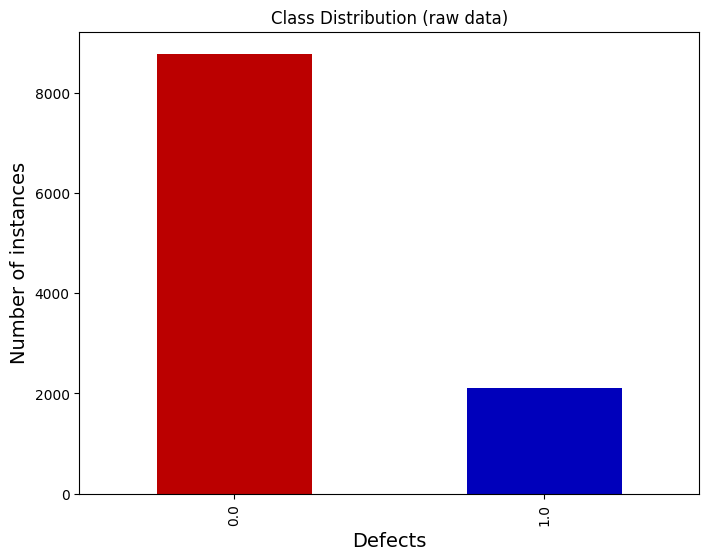

In [7]:
# Class distribution — shows imbalance
ax = Dataset['defects'].value_counts().plot(
    kind='bar', color=['#BB0000', '#0000BB'],
    title='Class Distribution (raw data)', figsize=(8, 6)
)
ax.set_xlabel("Defects", fontsize=14)
ax.set_ylabel("Number of instances", fontsize=14)
plt.show()

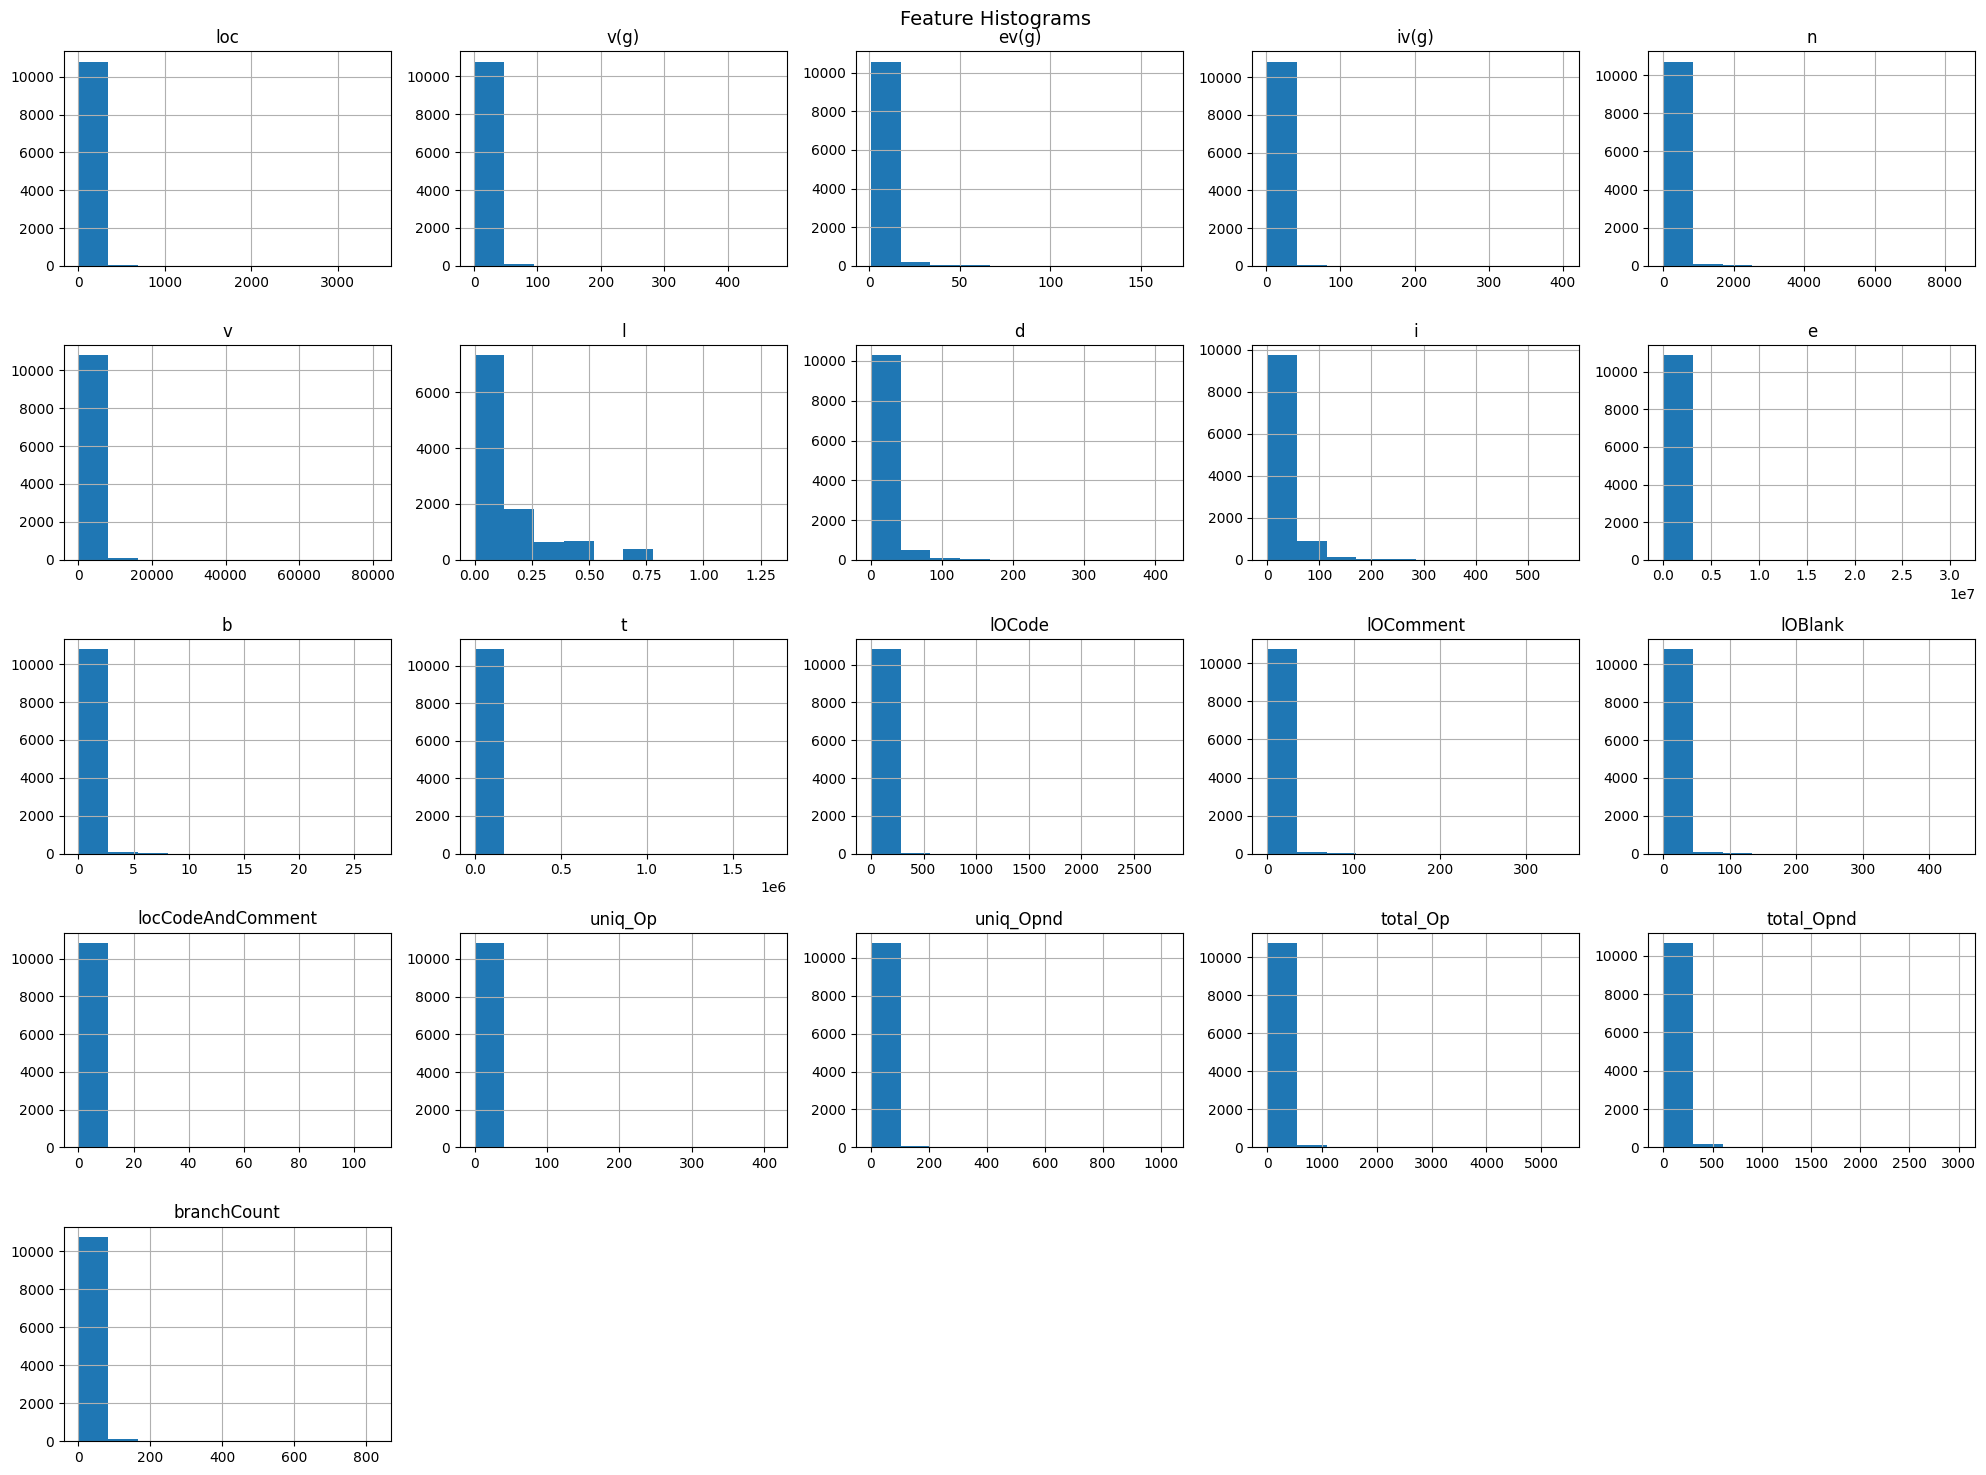

In [33]:
# Feature distributions
Dataset.iloc[:, :-1].hist(figsize=(20, 15))
plt.suptitle("Feature Histograms", fontsize=14)
plt.tight_layout()
plt.show()

## Step 3 — Correlation Analysis

A heatmap makes it far easier to spot redundant features than a raw number table.
Features with **|r| > 0.95** carry almost identical information — keeping both adds noise without adding signal.

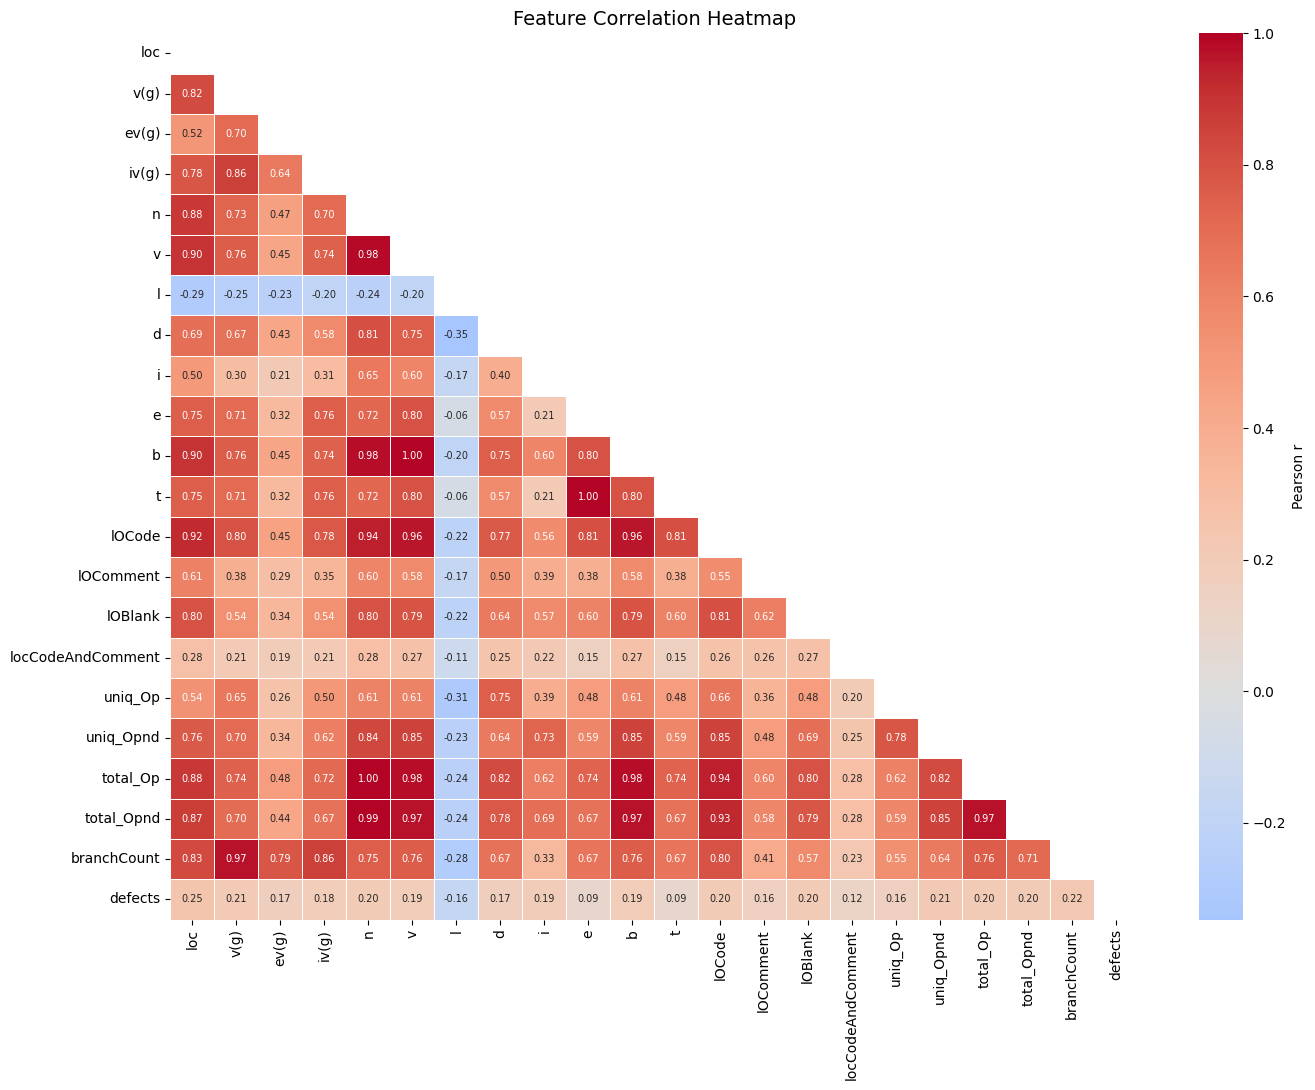

In [34]:
corr = Dataset.corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, annot_kws={'size': 7},
    cbar_kws={'label': 'Pearson r'}
)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [35]:
# Find all pairs with |r| > 0.95
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.95:
            high_corr_pairs.append((
                corr.columns[i], corr.columns[j], round(corr.iloc[i, j], 3)
            ))

print(f"Highly correlated pairs (|r| > 0.95): {len(high_corr_pairs)}")
for a, b, r in sorted(high_corr_pairs, key=lambda x: -abs(x[2])):
    print(f"  {a:22s} <-> {b:22s}  r = {r}")

Highly correlated pairs (|r| > 0.95): 14
  v                      <-> b                       r = 1.0
  e                      <-> t                       r = 1.0
  n                      <-> total_Op                r = 0.996
  n                      <-> total_Opnd              r = 0.989
  n                      <-> v                       r = 0.984
  n                      <-> b                       r = 0.984
  v                      <-> total_Op                r = 0.982
  b                      <-> total_Op                r = 0.981
  total_Op               <-> total_Opnd              r = 0.973
  v(g)                   <-> branchCount             r = 0.972
  v                      <-> total_Opnd              r = 0.972
  b                      <-> total_Opnd              r = 0.972
  v                      <-> lOCode                  r = 0.962
  b                      <-> lOCode                  r = 0.962


In [36]:
# From each pair, drop the one with LOWER correlation to the target
corr_with_target = corr['defects'].abs()

features_to_drop = set()
for a, b, r in high_corr_pairs:
    drop = b if corr_with_target.get(a, 0) >= corr_with_target.get(b, 0) else a
    features_to_drop.discard('defects')
    if drop != 'defects':
        features_to_drop.add(drop)

feature_cols_all     = [c for c in Dataset.columns if c != 'defects']
feature_cols_final   = [c for c in feature_cols_all if c not in features_to_drop]

print(f"Dropped ({len(features_to_drop)}): {sorted(features_to_drop)}")
print(f"\nKept   ({len(feature_cols_final)}): {feature_cols_final}")

Dropped (6): ['b', 'e', 'total_Op', 'total_Opnd', 'v', 'v(g)']

Kept   (15): ['loc', 'ev(g)', 'iv(g)', 'n', 'l', 'd', 'i', 't', 'lOCode', 'lOComment', 'lOBlank', 'locCodeAndComment', 'uniq_Op', 'uniq_Opnd', 'branchCount']


## Step 5 — NearMiss Undersampling

Applied **after** outlier removal and on the **reduced feature set**.
This is the correct order — outlier removal feeds into balancing, not the other way around.

In [39]:
X_clean = Dataset[feature_cols_final]
y_clean = Dataset['defects']

minority_n = int(y_clean.value_counts().min())
majority_n = min(3000, int(y_clean.value_counts()[0]))
minority_n = min(minority_n, 2103)

print(f"Resampling targets → majority: {majority_n}, minority: {minority_n}")

sampler = NearMiss(version=1, sampling_strategy={0: majority_n, 1: minority_n})
X_bal, y_bal = sampler.fit_resample(X_clean, y_clean)

print("\nClass distribution after NearMiss:")
print(pd.Series(y_bal).value_counts())

Resampling targets → majority: 3000, minority: 2103

Class distribution after NearMiss:
defects
0.0    3000
1.0    2103
Name: count, dtype: int64


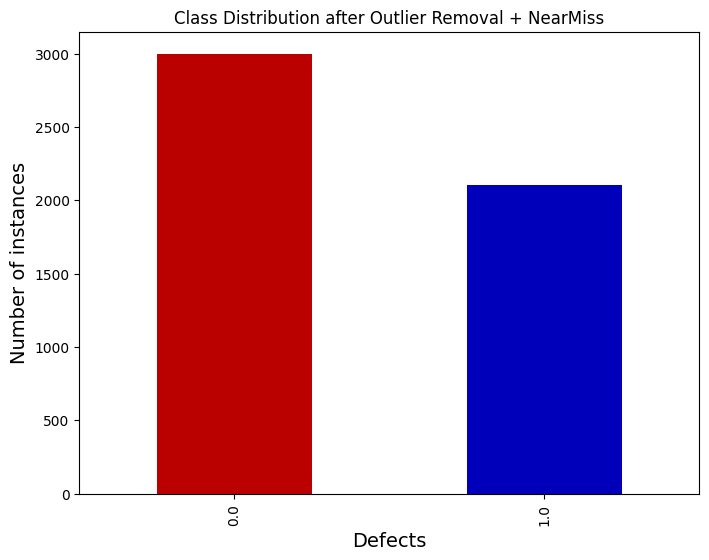

In [40]:
pd.Series(y_bal).value_counts().plot(
    kind='bar', color=['#BB0000', '#0000BB'],
    title='Class Distribution after Outlier Removal + NearMiss', figsize=(8, 6)
)
plt.xlabel("Defects", fontsize=14)
plt.ylabel("Number of instances", fontsize=14)
plt.show()

## Step 6 — Train/Test Split (70/30) + StandardScaler

- **30% test set** for a more reliable evaluation
- `stratify=y_bal` guarantees both splits stay balanced
- Scaler is **fit on train only**, then applied to test (no data leakage)

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal,
    test_size=0.30,
    random_state=42,
    stratify=y_bal
)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test  = sc.transform(X_test)

print(f"Train: {len(y_train)} samples  |  Test: {len(y_test)} samples")
print()
print("Train class distribution:")
print(pd.Series(y_train).value_counts())
print()
print("Test class distribution:")
print(pd.Series(y_test).value_counts())

Train: 3572 samples  |  Test: 1531 samples

Train class distribution:
defects
0.0    2100
1.0    1472
Name: count, dtype: int64

Test class distribution:
defects
0.0    900
1.0    631
Name: count, dtype: int64


## Evaluation Function

In [42]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    acc       = accuracy_score(y_te, y_pred)
    kfold     = model_selection.KFold(n_splits=5, shuffle=True, random_state=42)
    cv_acc    = cross_val_score(model, X_tr, y_tr, cv=kfold).mean()
    precision, recall, f1, _ = precision_recall_fscore_support(y_te, y_pred, average='macro')
    cm        = confusion_matrix(y_te, y_pred)
    roc_auc   = roc_auc_score(y_te, y_proba)

    return {
        "Model":       name,
        "Accuracy":    round(acc, 4),
        "CV Accuracy": round(cv_acc, 4),
        "Precision":   round(precision, 4),
        "Recall":      round(recall, 4),
        "F1-score":    round(f1, 4),
        "ROC-AUC":     round(roc_auc, 4),
        "Class 0 Acc": round(cm[0,0]/cm[0].sum(), 4),
        "Class 1 Acc": round(cm[1,1]/cm[1].sum(), 4),
    }

In [43]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Models

All models are trained on the **same data**:
- Reduced feature set (correlated features removed)
- Outliers removed (IQR)
- Balanced with NearMiss
- 70/30 stratified split
- StandardScaler applied

### Random Forest

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best CV F1:  0.8857


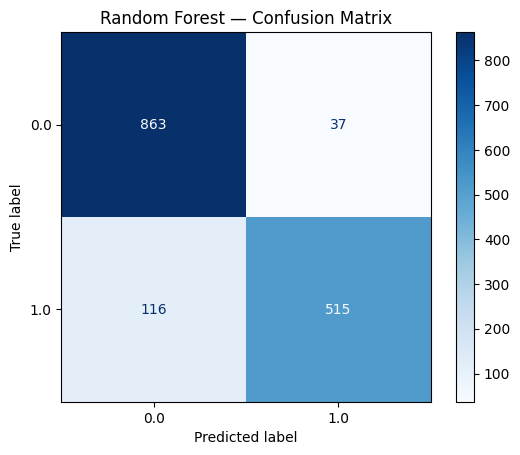

In [44]:
param_grid_rf = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf, scoring='f1_macro', cv=cv, n_jobs=-1, verbose=1
)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

print("Best params:", grid_rf.best_params_)
print("Best CV F1: ", round(grid_rf.best_score_, 4))
ConfusionMatrixDisplay.from_predictions(y_test, best_rf.predict(X_test), cmap='Blues')
plt.title("Random Forest — Confusion Matrix")
plt.show()

### Decision Tree

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best params: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best CV F1:  0.877


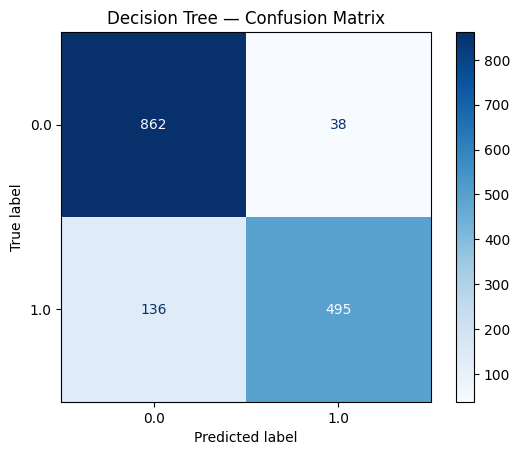

In [45]:
param_grid_tree = {
    'max_depth':         [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'criterion':         ['gini', 'entropy']
}

grid_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_tree, scoring='f1_macro', cv=cv, n_jobs=-1, verbose=1
)
grid_tree.fit(X_train, y_train)
best_tree = grid_tree.best_estimator_

print("Best params:", grid_tree.best_params_)
print("Best CV F1: ", round(grid_tree.best_score_, 4))
ConfusionMatrixDisplay.from_predictions(y_test, best_tree.predict(X_test), cmap='Blues')
plt.title("Decision Tree — Confusion Matrix")
plt.show()

### SVM

Fitting 5 folds for each of 35 candidates, totalling 175 fits
Best params: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
Best CV F1:  0.8839


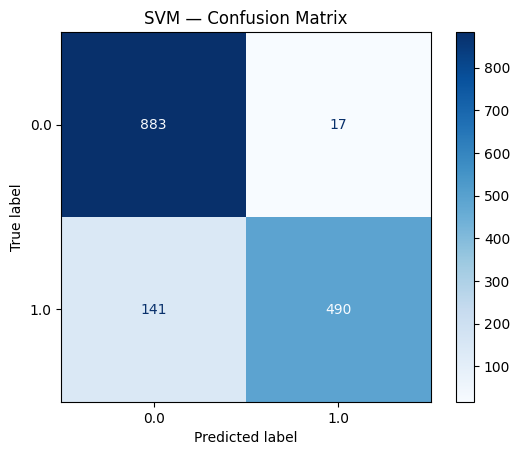

In [46]:
param_grid_svm = [
    {'kernel': ['linear'], 'C': [0.01, 0.1, 1, 10, 100]},
    {'kernel': ['rbf'],    'C': [0.01, 0.1, 1, 10, 100],
     'gamma':  ['scale', 'auto', 0.001, 0.01, 0.1, 1]}
]

grid_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid_svm, scoring='f1_macro', cv=cv, n_jobs=-1, verbose=1
)
grid_svm.fit(X_train, y_train)
best_svm = grid_svm.best_estimator_

print("Best params:", grid_svm.best_params_)
print("Best CV F1: ", round(grid_svm.best_score_, 4))
ConfusionMatrixDisplay.from_predictions(y_test, best_svm.predict(X_test), cmap='Blues')
plt.title("SVM — Confusion Matrix")
plt.show()

### KNN

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
Best CV F1:  0.8779


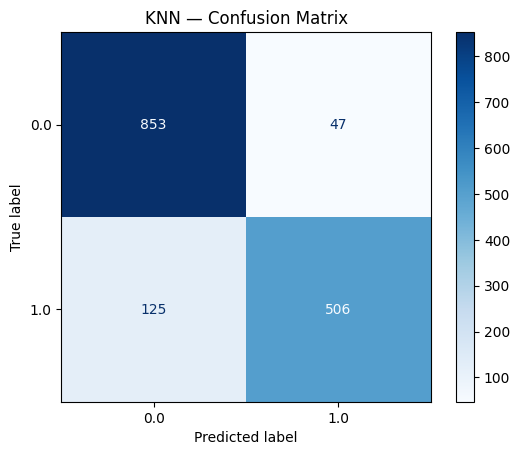

In [47]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn, scoring='f1_macro', cv=cv, n_jobs=-1, verbose=1
)
grid_knn.fit(X_train, y_train)
best_knn = grid_knn.best_estimator_

print("Best params:", grid_knn.best_params_)
print("Best CV F1: ", round(grid_knn.best_score_, 4))
ConfusionMatrixDisplay.from_predictions(y_test, best_knn.predict(X_test), cmap='Blues')
plt.title("KNN — Confusion Matrix")
plt.show()

### XGBoost

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params: {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Best CV F1:  0.8842


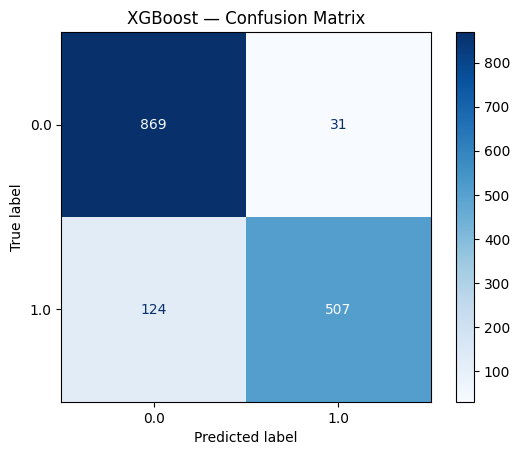

In [48]:
param_grid_xgb = {
    'n_estimators':     [100, 200],
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.01, 0.1],
    'subsample':        [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

grid_xgb = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid_xgb, scoring='f1_macro', cv=cv, n_jobs=-1, verbose=1
)
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

print("Best params:", grid_xgb.best_params_)
print("Best CV F1: ", round(grid_xgb.best_score_, 4))
ConfusionMatrixDisplay.from_predictions(y_test, best_xgb.predict(X_test), cmap='Blues')
plt.title("XGBoost — Confusion Matrix")
plt.show()

## Final Results

In [49]:
results = []
results.append(evaluate_model("XGBoost",      best_xgb,  X_train, y_train, X_test, y_test))
results.append(evaluate_model("Random Forest", best_rf,   X_train, y_train, X_test, y_test))
results.append(evaluate_model("SVM",           best_svm,  X_train, y_train, X_test, y_test))
results.append(evaluate_model("KNN",           best_knn,  X_train, y_train, X_test, y_test))
results.append(evaluate_model("Decision Tree", best_tree, X_train, y_train, X_test, y_test))

results_df = pd.DataFrame(results).sort_values("F1-score", ascending=False)
results_df

,Model,Accuracy,CV Accuracy,Precision,Recall,F1-score,ROC-AUC,Class 0 Acc,Class 1 Acc
1,Random Forest,0.9001,0.8914,0.9072,0.8875,0.8946,0.9433,0.9589,0.8162
0,XGBoost,0.8988,0.8908,0.9088,0.8845,0.8928,0.9462,0.9656,0.8035
2,SVM,0.8968,0.8886,0.9144,0.8788,0.8895,0.9115,0.9811,0.7765
3,KNN,0.8877,0.8821,0.8936,0.8748,0.8816,0.9152,0.9478,0.8019
4,Decision Tree,0.8863,0.8821,0.8962,0.8711,0.8794,0.9229,0.9578,0.7845


In [50]:
results_df.style.background_gradient(cmap='Blues')

,Model,Accuracy,CV Accuracy,Precision,Recall,F1-score,ROC-AUC,Class 0 Acc,Class 1 Acc
1,Random Forest,0.900100,0.891400,0.907200,0.887500,0.894600,0.943300,0.958900,0.816200
0,XGBoost,0.898800,0.890800,0.908800,0.884500,0.892800,0.946200,0.965600,0.803500
2,SVM,0.896800,0.888600,0.914400,0.878800,0.889500,0.911500,0.981100,0.776500
3,KNN,0.887700,0.882100,0.893600,0.874800,0.881600,0.915200,0.947800,0.801900
4,Decision Tree,0.886300,0.882100,0.896200,0.871100,0.879400,0.922900,0.957800,0.784500


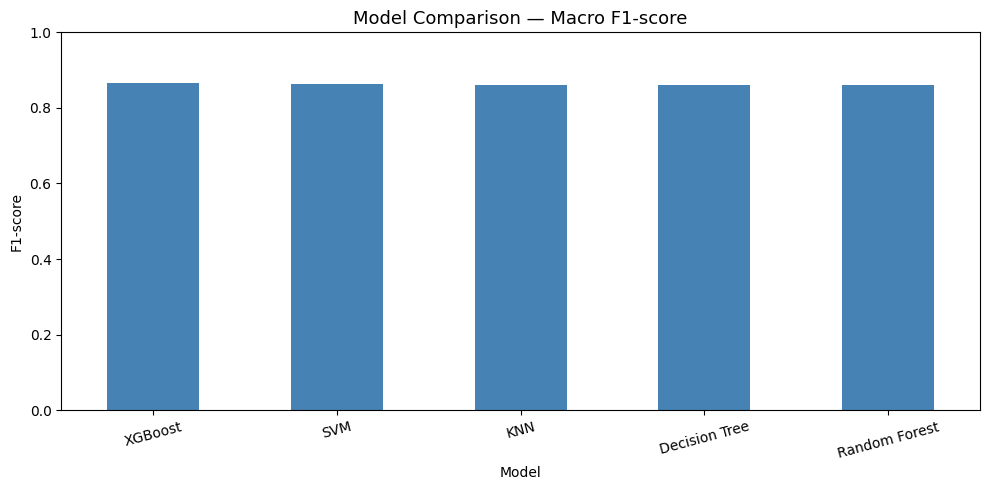

In [27]:
# Bar chart of F1-scores
results_df.plot(
    kind='bar', x='Model', y='F1-score',
    color='steelblue', figsize=(10, 5), legend=False
)
plt.title("Model Comparison — Macro F1-score", fontsize=13)
plt.ylabel("F1-score")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()